# 8. CNNを用いた層化5分割交差検証

## 8.1 ライブラリのインポート

In [5]:
# !pip install -q tensorflow-gpu==2.0.0-beta1
import tensorflow as tf

from tensorflow.keras import datasets, layers, models, optimizers, regularizers
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2

## 8.2 GPCRデータセットのグラフ表示画像の準備

In [6]:
with open("gpcr_labels_exclusion.csv") as f:
    reader = csv.reader(f)
    l = [row for row in reader]

labels = []
for i in range(len(l)):
    labels.append(l[i][1])

## 8.3 ハイパーパラメータの設定

In [7]:
batch_size = 128
lr = 1e-3
l2_size = 0
epochs = 20
dropout = 0

num_classes = 5
data_size = 7612
seed = 42
np.random.seed(seed)

X = np.load("./graphs/prott5_exclusion/pca15umap2_cog_nn100_md0_scaled_10_170.npy") # このファイルはラベルの作成以外に使用しない
X = np.array(X)
print(X.shape)

X = X.reshape(data_size, 150, 150, 1)
X = X.astype('float32')
X /= 255.0
print(type(X))

le = LabelEncoder()
y = le.fit_transform(labels)
print(y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, valid_idx in skf.split(X, y):
    print("train_index:", train_idx, "valid_index:", valid_idx)
    print(train_idx.shape, valid_idx.shape)

(7612, 150, 150)
<class 'numpy.ndarray'>
[0 0 0 ... 4 4 4]
train_index: [   0    1    3 ... 7609 7610 7611] valid_index: [   2   10   11 ... 7601 7603 7606]
(6089,) (1523,)
train_index: [   0    2    3 ... 7607 7609 7611] valid_index: [   1    9   13 ... 7602 7608 7610]
(6089,) (1523,)
train_index: [   1    2    5 ... 7609 7610 7611] valid_index: [   0    3    4 ... 7597 7599 7605]
(6090,) (1522,)
train_index: [   0    1    2 ... 7609 7610 7611] valid_index: [   7   17   19 ... 7595 7598 7604]
(6090,) (1522,)
train_index: [   0    1    2 ... 7606 7608 7610] valid_index: [   5    6    8 ... 7607 7609 7611]
(6090,) (1522,)


## 8.4 CNNモデルの設定および実行

In [8]:
results = []
pred_result = []
model_name = "prott5"
method_name = "pcaotsne2_cog_ut"  # 使った次元削減の手法
dir_name = "fold_pcaotsne2_cog_ppx5_cosine_cv2"

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}")
    # trainデータの整形
    train_imgs = []
    for idx in train_idx:
        img = cv2.imread(f"./graphs/{model_name}_exclusion/{dir_name}/fold{fold + 1}_train_{method_name}/{idx + 1}_pcaotsne2.png", cv2.IMREAD_GRAYSCALE)
        train_imgs.append(img)
    train_imgs = np.array(train_imgs)
    train_size = train_imgs.shape[0]
    train_imgs.reshape(train_size, 150, 150, 1)
    train_imgs = train_imgs.astype('float32')
    train_imgs /= 255.0
    print(train_imgs.shape)

    # testデータの整形
    test_imgs = []
    for idx in valid_idx:
        img = cv2.imread(f"./graphs/{model_name}_exclusion/{dir_name}/fold{fold + 1}_test_{method_name}/{idx + 1}_pcaotsne2.png", cv2.IMREAD_GRAYSCALE)
        test_imgs.append(img)
    test_imgs = np.array(test_imgs)
    test_size = test_imgs.shape[0]
    test_imgs.reshape(test_size, 150, 150, 1)
    test_imgs = test_imgs.astype('float32')
    test_imgs /= 255.0
    print(test_imgs.shape)
    
    #X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]
    #print(X_train.shape, X_valid.shape)
    print(type(train_imgs), type(y_train))

    train_data = list(zip(train_imgs, y_train))
    np.random.shuffle(train_data)
    train_imgs, y_train = zip(*train_data)
    train_imgs, y_train = np.array(train_imgs), np.array(y_train)    
    print(type(train_imgs), type(y_train))
    print(y_train)

    model = models.Sequential()
    model.add(layers.Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(16, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    if l2_size > 0:
        model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_size)))
    else:
        model.add(layers.Dense(64, activation='relu'))
    if dropout > 0:
        model.add(layers.Dropout(dropout, seed = seed))
    if l2_size > 0:
        model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_size)))
    else:
        model.add(layers.Dense(64, activation='relu'))
    if dropout > 0:
        model.add(layers.Dropout(dropout, seed = seed))
    if l2_size > 0:
        model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_size)))
    else:
        model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(5, activation='softmax'))

    optimizer = optimizers.Adam(learning_rate=lr)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['sparse_categorical_accuracy'])
    
    #model.summary()

    history = model.fit(train_imgs, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2) #validation_split=0.2だと末尾の20%が使われるからダメ
    pred_history = model.predict(test_imgs)

    history_dict = history.history
    results.append(history_dict)
    pred_result.append(pred_history)


Fold 1
(6089, 150, 150)
(1523, 150, 150)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
[0 0 2 ... 2 2 0]
Epoch 1/20


c:\Users\haivu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.7808 - sparse_categorical_accuracy: 0.7571 - val_loss: 0.4436 - val_sparse_categorical_accuracy: 0.8662
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.4073 - sparse_categorical_accuracy: 0.8668 - val_loss: 0.3457 - val_sparse_categorical_accuracy: 0.8900
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.3082 - sparse_categorical_accuracy: 0.9088 - val_loss: 0.2920 - val_sparse_categorical_accuracy: 0.9072
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.2372 - sparse_categorical_accuracy: 0.9253 - val_loss: 0.2253 - val_sparse_categorical_accuracy: 0.9384
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.1885 - sparse_categorical_accuracy: 0.9394 - val_loss: 0.2276 - val_sparse_categorical_accuracy: 0.9286
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.1532 - sparse_categorical_accuracy: 0.9516 - val_loss: 0.1688 - val_sparse_categorical_accuracy: 0.9466
Epoch 7/20
39/3

## 8.5 学習曲線の表示

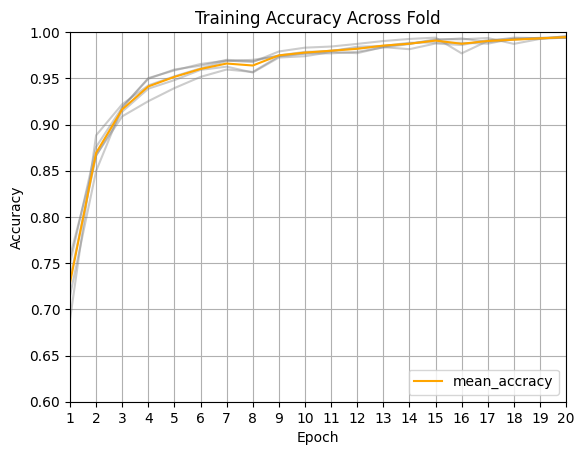

In [9]:
acc_all = []
for i in range(len(results)):
    plt.plot(np.arange(1, epochs+1, 1), results[i]['sparse_categorical_accuracy'], color="gray", alpha=0.4)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.xlim([1, epochs])
    plt.xticks(np.arange(1, epochs+1, 1))
    plt.ylim([0.6, 1])
    acc_all.append(results[i]['sparse_categorical_accuracy'])
acc_all = np.vstack(acc_all)
acc_avg = acc_all.mean(axis=0)
plt.title("Training Accuracy Across Fold")
plt.plot(np.arange(1, epochs+1, 1), acc_avg, color="orange", label="mean_accracy")
plt.legend(loc='lower right')

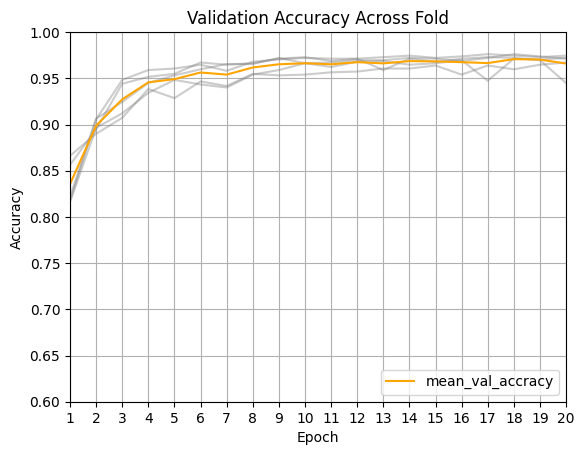

In [10]:
val_acc_all = []
for i in range(len(results)):
    plt.plot(np.arange(1, epochs+1, 1), results[i]['val_sparse_categorical_accuracy'], color="gray", alpha=0.4)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.xlim([1, epochs])
    plt.xticks(np.arange(1, epochs+1, 1))
    plt.ylim([0.6, 1])
    val_acc_all.append(results[i]['val_sparse_categorical_accuracy'])
val_acc_all = np.vstack(val_acc_all)
val_acc_avg = val_acc_all.mean(axis=0)
plt.title("Validation Accuracy Across Fold")
plt.plot(np.arange(1, epochs+1, 1), val_acc_avg, color="orange", label="mean_val_accracy")
plt.legend(loc='lower right')

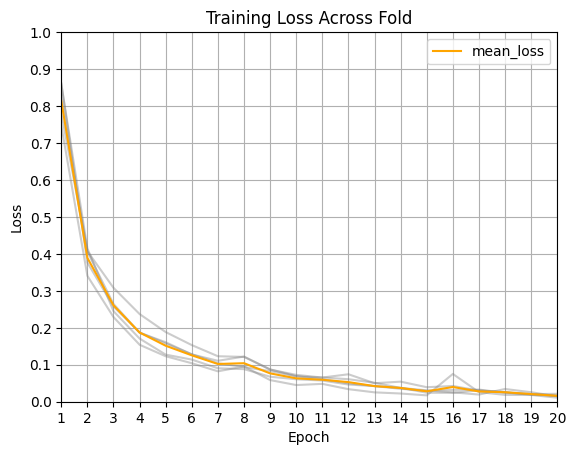

In [11]:
loss_all = []
for i in range(len(results)):
    plt.plot(np.arange(1, epochs+1, 1), results[i]['loss'], color="gray", alpha=0.4)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.xlim([1, epochs])
    plt.xticks(np.arange(1, epochs+1, 1))
    plt.ylim([0, 1])
    plt.yticks(np.arange(0, 1.1, 0.1))
    loss_all.append(results[i]['loss'])
loss_all = np.vstack(loss_all)
loss_avg = loss_all.mean(axis=0)
plt.title("Training Loss Across Fold")
plt.plot(np.arange(1, epochs+1, 1), loss_avg, color="orange", label="mean_loss")
plt.legend(loc='upper right')

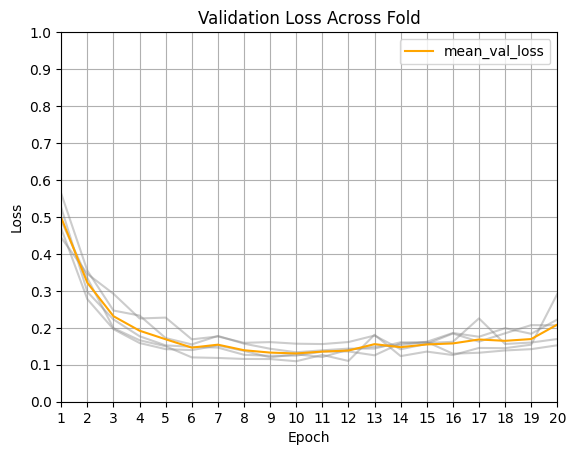

In [12]:
val_loss_all = []
for i in range(len(results)):
    plt.plot(np.arange(1, epochs+1, 1), results[i]['val_loss'], color="gray", alpha=0.4)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.xlim([1, epochs])
    plt.xticks(np.arange(1, epochs+1, 1))
    plt.ylim([0, 1])
    plt.yticks(np.arange(0, 1.1, 0.1))
    val_loss_all.append(results[i]['val_loss'])
val_loss_all = np.vstack(val_loss_all)
val_loss_avg = val_loss_all.mean(axis=0)
plt.title("Validation Loss Across Fold")
plt.plot(np.arange(1, epochs+1, 1), val_loss_avg, color="orange", label="mean_val_loss")
plt.legend(loc='upper right')

## 8.6 予測結果の作成

In [13]:
pred_labels = [[] for _ in range(5)]
true_labels = []
micro_data_size = []

for i in range(len(pred_result)):
    for j in range(len(pred_result[i])):
        pre = pred_result[i][j].tolist()
        pred_labels[i].append(pre.index(max(pre)))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    true_labels.append(y[valid_idx].tolist())
    micro_data_size.append(len(valid_idx))
print(micro_data_size)

[1523, 1523, 1522, 1522, 1522]


## 8.7 混同行列の作成と表示

[[1034    2   12    0    0]
 [  11   73    3    0    0]
 [  18    3  361    0    0]
 [   0    0    1    1    0]
 [   0    0    0    0    4]]
[np.int64(1034), np.int64(73), np.int64(361), np.int64(1), np.int64(4)] [np.int64(439), np.int64(1400), np.int64(1112), np.int64(1472), np.int64(1469)] [np.int64(29), np.int64(5), np.int64(16), np.int64(0), np.int64(0)] [np.int64(14), np.int64(14), np.int64(21), np.int64(1), np.int64(0)]
ClassA F1 score:0.9796
ClassB F1 score:0.8848
ClassC F1 score:0.9513
ClassD F1 score:0.6667
ClassE F1 score:1.0000
Fold1: F1 score:0.8965


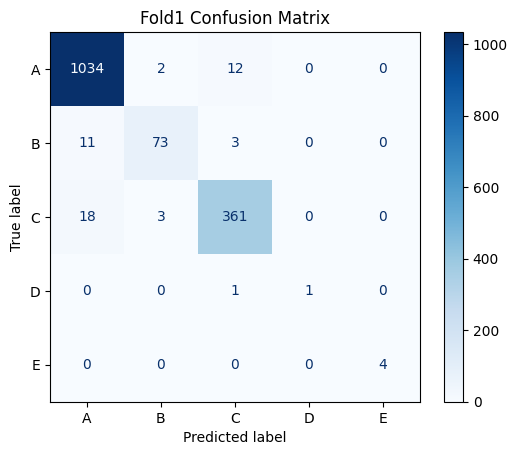

[[1039    5    3    0    0]
 [   8   79    0    0    0]
 [  35   21  325    1    0]
 [   0    0    0    3    0]
 [   1    0    0    0    3]]
[np.int64(1039), np.int64(79), np.int64(325), np.int64(3), np.int64(3)] [np.int64(410), np.int64(1370), np.int64(1124), np.int64(1446), np.int64(1446)] [np.int64(44), np.int64(26), np.int64(3), np.int64(1), np.int64(0)] [np.int64(8), np.int64(8), np.int64(57), np.int64(0), np.int64(1)]
ClassA F1 score:0.9756
ClassB F1 score:0.8229
ClassC F1 score:0.9155
ClassD F1 score:0.8571
ClassE F1 score:0.8571
Fold2: F1 score:0.8857


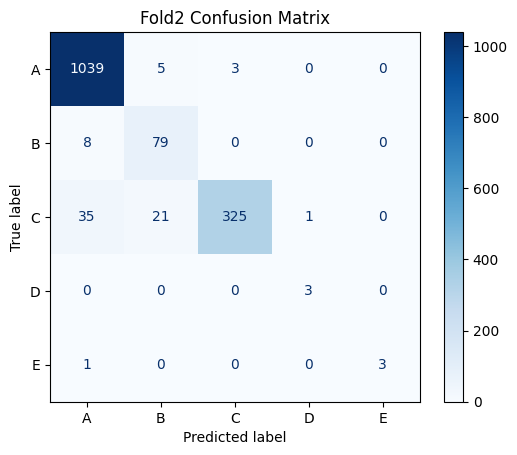

[[1035    3    7    0    2]
 [   3   78    6    0    0]
 [  15    4  361    1    1]
 [   0    0    1    2    0]
 [   1    0    1    0    1]]
[np.int64(1035), np.int64(78), np.int64(361), np.int64(2), np.int64(1)] [np.int64(442), np.int64(1399), np.int64(1116), np.int64(1475), np.int64(1476)] [np.int64(19), np.int64(7), np.int64(15), np.int64(1), np.int64(3)] [np.int64(12), np.int64(9), np.int64(21), np.int64(1), np.int64(2)]
ClassA F1 score:0.9852
ClassB F1 score:0.9070
ClassC F1 score:0.9525
ClassD F1 score:0.6667
ClassE F1 score:0.2857
Fold3: F1 score:0.7594


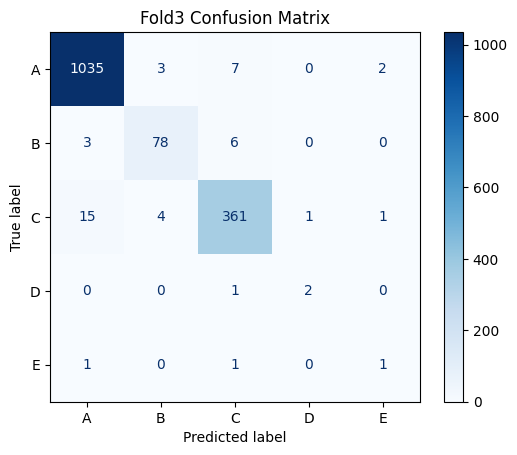

[[1029    0   18    0    0]
 [   9   66   12    0    0]
 [  14    4  364    0    0]
 [   0    0    2    1    0]
 [   0    0    0    0    3]]
[np.int64(1029), np.int64(66), np.int64(364), np.int64(1), np.int64(3)] [np.int64(434), np.int64(1397), np.int64(1099), np.int64(1462), np.int64(1460)] [np.int64(23), np.int64(4), np.int64(32), np.int64(0), np.int64(0)] [np.int64(18), np.int64(21), np.int64(18), np.int64(2), np.int64(0)]
ClassA F1 score:0.9805
ClassB F1 score:0.8408
ClassC F1 score:0.9357
ClassD F1 score:0.5000
ClassE F1 score:1.0000
Fold4: F1 score:0.8514


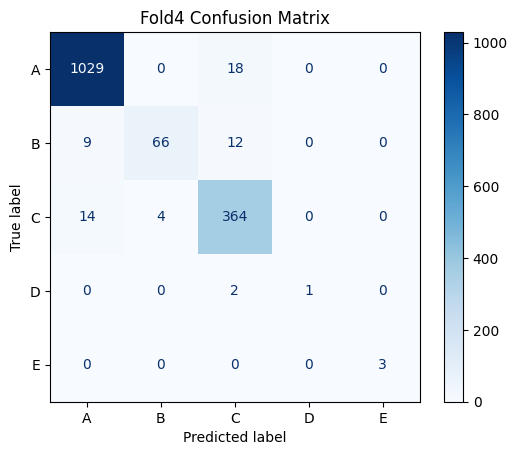

[[1038    2    7    0    0]
 [   3   82    2    0    0]
 [   9    1  372    0    0]
 [   1    0    1    0    0]
 [   0    0    0    0    4]]
[np.int64(1038), np.int64(82), np.int64(372), np.int64(0), np.int64(4)] [np.int64(458), np.int64(1414), np.int64(1124), np.int64(1496), np.int64(1492)] [np.int64(13), np.int64(3), np.int64(10), np.int64(0), np.int64(0)] [np.int64(9), np.int64(5), np.int64(10), np.int64(2), np.int64(0)]
ClassA F1 score:0.9895
ClassB F1 score:0.9535
ClassC F1 score:0.9738
ClassD F1 score:0.0000
ClassE F1 score:1.0000
Fold5: F1 score:0.7834


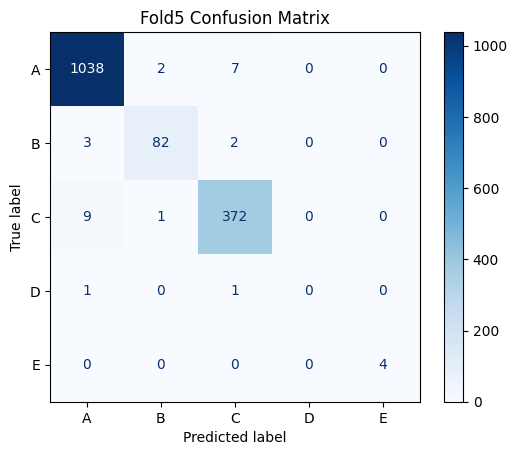

In [14]:
Acc = 0
MacroF1 = 0
for fold in range(5):
    fixed_labels = ["A", "B", "C", "D", "E"]
    cm = confusion_matrix(true_labels[fold], pred_labels[fold])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
    print(cm)

    cm_t = cm.T
    TP = []
    TN = []
    FP = []
    FN = []
    sum_tp = 0
    f1 = []

    for i in range(num_classes):
        TP.append(cm[i][i])
        FP.append(sum(cm_t[i]) - cm_t[i][i])
        FN.append(sum(cm[i]) - cm[i][i])

        sum_tp += cm[i][i]
    
    Acc += sum_tp / micro_data_size[i]
    
    for i in range(num_classes):
        TN.append(sum_tp - cm[i][i])

    print(TP,TN,FP,FN)
    for i in range(num_classes):
        f1.append(2 * TP[i] / (2 * TP[i] + FP[i] + FN[i]))

    MacroF1 += sum(f1)/len(f1)

    for i in range(num_classes):
        print(f"Class{fixed_labels[i]} F1 score:{f1[i]:.4f}")

    print(f"Fold{fold + 1}: F1 score:{sum(f1)/len(f1):.4f}")

    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(f"Fold{fold + 1} Confusion Matrix")
    plt.show()

## 8.8 評価指標の計算と表示

[[5175   12   47    0    2]
 [  34  378   23    0    0]
 [  91   33 1783    2    1]
 [   1    0    5    7    0]
 [   2    0    1    0   15]]
[np.int64(5175), np.int64(378), np.int64(1783), np.int64(7), np.int64(15)] [np.int64(2183), np.int64(6980), np.int64(5575), np.int64(7351), np.int64(7343)] [np.int64(128), np.int64(45), np.int64(76), np.int64(2), np.int64(3)] [np.int64(61), np.int64(57), np.int64(127), np.int64(6), np.int64(3)]
Macro Accuracy:0.9669
Macro F1 score:0.8353


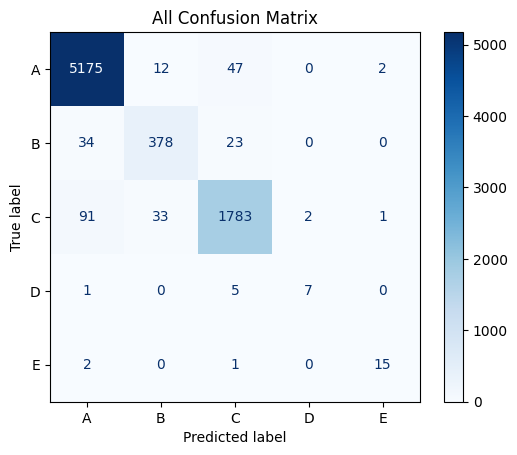

In [16]:
import itertools

fixed_labels = ["A", "B", "C", "D", "E"]
true_labels_fl = list(itertools.chain.from_iterable(true_labels))
pred_labels_fl = list(itertools.chain.from_iterable(pred_labels))
cm = confusion_matrix(true_labels_fl, pred_labels_fl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
print(cm)

cm_t = cm.T
TP = []
TN = []
FP = []
FN = []
sum_tp = 0
f1 = []

for i in range(num_classes):
    TP.append(cm[i][i])
    FP.append(sum(cm_t[i]) - cm_t[i][i])
    FN.append(sum(cm[i]) - cm[i][i])

    sum_tp += cm[i][i]
    
for i in range(num_classes):
    TN.append(sum_tp - cm[i][i])

print(TP,TN,FP,FN)
for i in range(num_classes):
    f1.append(2 * TP[i] / (2 * TP[i] + FP[i] + FN[i]))

# for i in range(num_classes):
    # print(f"Class{fixed_labels[i]} F1 score:{f1[i]:.4f}")

# print(f"All accuracy:{sum(TP) / data_size:.4f}")
# print(f"All F1 score:{sum(f1) / num_classes:.4f}")

print(f"Macro Accuracy:{(Acc / 5):.4f}")
print(f"Macro F1 score:{(MacroF1 / 5):.4f}")

disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("All Confusion Matrix")
plt.show()